Accompanies Section `subsec:ft_envelope` (Fourier Transform: Spot Evolution Envelope Term $\Gamma(t)$), item (1), Eq. `eq:Gamma_hat`, and its derivation in Appendix `app:fourier_trapezoid` (Fourier Transform of the Trapezoidal Envelope) of the paper.

# Fourier Transform of $\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$

Derive and verify the closed-form FT $\hat\Gamma(\omega)$ of the normalized squared trapezoidal envelope, Eq. `eq:Gamma_hat` (= Eq. `eq:Gamma_hat_direct`), with the paper's convention $\hat f(\omega) = \int_{-\infty}^{\infty} f(t)\,e^{-i\omega t}\,dt$. As in Appendix `app:fourier_trapezoid` we write $\ell \equiv \ell_{\rm spot}$ and $\tau \equiv \tau_{\rm spot}$.

**Normalization.** $\Gamma(t)$ has unit peak (Eq. `eq:Gamma_piecewise`), so $\hat\Gamma(\omega)$ carries no factor of $\alpha_{\max}^2$. The physical squared envelope is $\alpha^2(t) = \alpha_{\max}^2\,\Gamma(t)$, with transform $\alpha_{\max}^2\,\hat\Gamma(\omega)$; in the paper the $\alpha_{\max}^2$ is carried separately ($A(t)/\pi = \alpha_{\max}^2\,\Gamma(t)\,\mathcal{V}(t)$, and $\mathcal{K}(\tau) = \alpha_{\max}^4 R_\Gamma(\tau)[\dots]$ in Eq. `eq:kernel_single_spot`). The unsquared trapezoid $\alpha(t)$ and its transform $\hat\alpha(\omega)$, which the paper does not typeset, are derived in [`ft_trapezoid.ipynb`](ft_trapezoid.ipynb); here $\hat\alpha$ is used only for comparison and as a cross-check (Sections 2–4).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *
import spotgp.envelope as spotgp_envelope
plt.rcdefaults()   # importing spotgp switches matplotlib to the 'classic' style with usetex; restore the defaults
init_printing()


def vanishes(expr):
    """True if a SymPy expression simplifies to zero."""
    return simplify(expand_trig(expr)) == 0

## 1. Symbolic derivation via direct integration (Appendix `app:fourier_trapezoid`)

The normalized squared trapezoid (Eq. `eq:Gamma_piecewise`) is
$$\Gamma(t) = \frac{\alpha^2(t)}{\alpha_{\max}^2} = \begin{cases} 0 & |t| > \ell/2 + \tau \\ \left(\dfrac{|t| - \ell/2 - \tau}{-\tau}\right)^{2} & \ell/2 < |t| \le \ell/2 + \tau \\ 1 & |t| \le \ell/2 \end{cases}$$

Since $\Gamma(t)$ is real and even (property `ft:even`):
$$\hat{\Gamma}(\omega) = 2\int_0^\infty \Gamma(t)\cos(\omega t)\,dt = 2\left[\underbrace{\int_0^{\ell/2} \cos(\omega t)\,dt}_{I_1} + \underbrace{\int_{\ell/2}^{\ell/2+\tau} \left(\frac{\ell/2+\tau-t}{\tau}\right)^2 \cos(\omega t)\,dt}_{I_2}\right]$$

SymPy evaluates each piece below and checks it against the paper's intermediate steps:
- $I_1$ (plateau): Eq. `eq:I1_plateau`;
- $J = \int_a^b (b-t)\sin(\omega t)\,dt$ with $a = \ell/2$, $b = \ell/2 + \tau$ (the second integration by parts): Eq. `eq:J_ibp`;
- $I_2$ (parabolic ramp) $= -\sin(\omega\ell/2)/\omega + \frac{2}{\tau^2\omega}J$ (first integration by parts): Eq. `eq:I2_ramp`;
- $I_1 + I_2$, in which the $\sin(\omega\ell/2)/\omega$ terms cancel: Eq. `eq:I1_plus_I2`;
- $\hat\Gamma = 2(I_1 + I_2)$: Eq. `eq:Gamma_hat_direct`, i.e. Eq. `eq:Gamma_hat` with $\ell = \ell_{\rm spot}$, $\tau = \tau_{\rm spot}$.

I1 == Eq. eq:I1_plateau: True
I1 =


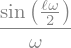

In [2]:
t, w, ell, tau = symbols('t omega ell tau', positive=True)
a = ell / 2
b = ell / 2 + tau

# I1: plateau integral
I1 = integrate(cos(w * t), (t, 0, a))
I1_paper = sin(w * ell / 2) / w                                    # Eq. eq:I1_plateau
print("I1 == Eq. eq:I1_plateau:", vanishes(I1 - I1_paper))
assert vanishes(I1 - I1_paper)
print("I1 =")
I1

J == Eq. eq:J_ibp: True
J =


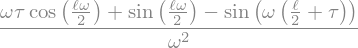

In [3]:
# J: the integral left after the first integration by parts of I2
J = integrate((b - t) * sin(w * t), (t, a, b))
J_paper = tau * cos(w * ell / 2) / w - (sin(w * b) - sin(w * ell / 2)) / w**2    # Eq. eq:J_ibp
print("J == Eq. eq:J_ibp:", vanishes(J - J_paper))
assert vanishes(J - J_paper)
print("J =")
simplify(J)

I2 == -sin(omega ell/2)/omega + (2/(tau^2 omega)) J: True
I2 == Eq. eq:I2_ramp: True


I2 (simplified) =


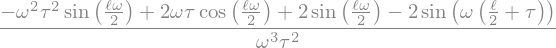

In [4]:
# I2: parabolic ramp integral
ramp_squared = ((b - t) / tau)**2
I2 = integrate(ramp_squared * cos(w * t), (t, a, b))
I2_simplified = simplify(I2)

# First integration by parts: boundary term -sin(omega*ell/2)/omega plus (2/(tau^2 omega)) J
I2_ibp = -sin(w * ell / 2) / w + 2 / (tau**2 * w) * J_paper
I2_paper = (-sin(w * ell / 2) / w + 2 * cos(w * ell / 2) / (tau * w**2)
            - 2 * (sin(w * ell / 2 + w * tau) - sin(w * ell / 2)) / (tau**2 * w**3))  # Eq. eq:I2_ramp
print("I2 == -sin(omega ell/2)/omega + (2/(tau^2 omega)) J:", vanishes(I2 - I2_ibp))
print("I2 == Eq. eq:I2_ramp:", vanishes(I2 - I2_paper))
assert vanishes(I2 - I2_ibp) and vanishes(I2 - I2_paper)
print("I2 (simplified) =")
I2_simplified

I1 + I2 == Eq. eq:I1_plus_I2: True


Γ̂(ω) =


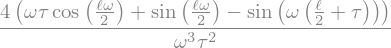

In [5]:
# I1 + I2 (Eq. eq:I1_plus_I2): the sin(omega*ell/2)/omega terms cancel
I12_paper = (2 * cos(w * ell / 2) / (tau * w**2) + 2 * sin(w * ell / 2) / (tau**2 * w**3)
             - 2 * sin(w * ell / 2 + w * tau) / (tau**2 * w**3))
print("I1 + I2 == Eq. eq:I1_plus_I2:", vanishes(I1 + I2 - I12_paper))
assert vanishes(I1 + I2 - I12_paper)

# Full FT of the normalized Gamma(t) (no alpha_max^2 factor)
Gamma_hat_sym = simplify(2 * (I1 + I2))
print("Γ̂(ω) =")
Gamma_hat_sym

In [6]:
# Compare with the paper's closed form, Eq. eq:Gamma_hat (= eq:Gamma_hat_direct)
Gamma_hat_paper = 4 / (tau**2 * w**3) * (
    tau * w * cos(w * ell / 2)
    + sin(w * ell / 2)
    - sin(w * ell / 2 + w * tau)
)

diff = simplify(trigsimp(Gamma_hat_sym - Gamma_hat_paper))
assert diff == 0
print("Γ̂(ω) - Eq. eq:Gamma_hat (should be 0):")
diff

Γ̂(ω) - Eq. eq:Gamma_hat (should be 0):


In [7]:
# DC limit: Gamma_hat(0) = area under Gamma(t) = ell + 2 tau/3
dc_limit = limit(Gamma_hat_paper, w, 0)
area = integrate(1, (t, -a, a)) + 2 * integrate(ramp_squared, (t, a, b))
print("Γ̂(0) =", simplify(dc_limit))
print("∫Γ(t) dt =", simplify(area))
print("Expected: ℓ + 2τ/3 =", ell + 2*tau/3)
print("Match:", simplify(dc_limit - area) == 0 and simplify(dc_limit - (ell + 2*tau/3)) == 0)
assert simplify(dc_limit - area) == 0 and simplify(dc_limit - (ell + 2*tau/3)) == 0

Γ̂(0) = ell + 2*tau/3
∫Γ(t) dt = ell + 2*tau/3
Expected: ℓ + 2τ/3 = ell + 2*tau/3
Match: True


## 2. Numerical verification against FFT

Compare Eq. `eq:Gamma_hat` against a numerical FFT of $\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$, and against the implementation in `spotgp` (`spotgp.envelope._Gamma_hat(omega, ell, tau_spot)`). We use $\alpha_{\max} \neq 1$ on purpose: $\Gamma$ and $\hat\Gamma$ do not depend on it, while $\hat\alpha$ scales with it.

In [8]:
# Physical parameters
ell_val = 20.0    # plateau duration ell_spot [days]
tau_val = 5.0     # ramp (emergence/decay) duration tau_spot [days]
amax = 0.1        # peak angular radius alpha_max [rad]; Gamma(t) does not depend on it

def trapezoid(t, ell, tau, amax):
    """Trapezoidal envelope alpha(t) centered at 0, Eq. eq:alpha_piecewise."""
    half_ell = ell / 2
    result = np.zeros_like(t)
    mask_rise = (t >= -(half_ell + tau)) & (t < -half_ell)
    result[mask_rise] = amax * (t[mask_rise] + half_ell + tau) / tau
    mask_flat = (np.abs(t) <= half_ell)
    result[mask_flat] = amax
    mask_fall = (t > half_ell) & (t <= half_ell + tau)
    result[mask_fall] = amax * (-(t[mask_fall] - half_ell) + tau) / tau
    return result

def Gamma_hat_analytic(omega, ell, tau):
    """Eq. eq:Gamma_hat: FT of the normalized Gamma(t) = alpha^2(t)/alpha_max^2."""
    result = np.zeros_like(omega)
    nz = np.abs(omega) > 1e-14
    w = omega[nz]
    result[nz] = (4 / (tau**2 * w**3) *
                  (tau * w * np.cos(w * ell / 2)
                   + np.sin(w * ell / 2)
                   - np.sin(w * ell / 2 + w * tau)))
    result[~nz] = ell + 2*tau/3
    return result

def alpha_hat_analytic(omega, ell, tau, amax):
    """FT of the unsquared trapezoid alpha(t) (ft_trapezoid.ipynb; not typeset in the paper)."""
    result = np.zeros_like(omega)
    nz = np.abs(omega) > 1e-14
    w = omega[nz]
    result[nz] = (2 * amax / (w**2 * tau) *
                  (np.cos(w * ell / 2) - np.cos(w * ell / 2 + w * tau)))
    result[~nz] = amax * (ell + tau)
    return result

In [9]:
# FFT computation
N = 2**16
T_total = 200.0
dt = T_total / N
t_arr = np.linspace(-T_total/2, T_total/2, N, endpoint=False)

alpha_t = trapezoid(t_arr, ell_val, tau_val, amax)
Gamma_t = alpha_t**2 / amax**2          # normalized squared envelope, Eq. eq:Gamma_piecewise

# FFT (with shift for centered signal)
Gamma_hat_fft = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(Gamma_t))) * dt
alpha_hat_fft = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(alpha_t))) * dt
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=dt)) * 2 * np.pi  # angular frequency

# Analytic
Gamma_hat_ana = Gamma_hat_analytic(freqs, ell_val, tau_val)
alpha_hat_ana = alpha_hat_analytic(freqs, ell_val, tau_val, amax)

print(f"DC check: Γ̂(0) analytic = ℓ + 2τ/3      = {ell_val + 2*tau_val/3:.4f}")
print(f"DC check: Γ̂(0) FFT                      = {Gamma_hat_fft[N//2].real:.4f}")
print(f"DC check: α̂(0) analytic = α_max(ℓ + τ)  = {amax * (ell_val + tau_val):.4f}")
print(f"DC check: α̂(0) FFT                      = {alpha_hat_fft[N//2].real:.4f}")
assert abs(Gamma_hat_fft[N//2].real - (ell_val + 2*tau_val/3)) < 1e-6
assert abs(alpha_hat_fft[N//2].real - amax * (ell_val + tau_val)) < 1e-6

# Eq. eq:Gamma_hat is what spotgp implements
Gamma_hat_spotgp = np.asarray(spotgp_envelope._Gamma_hat(freqs, ell_val, tau_val))
spotgp_err = np.max(np.abs(Gamma_hat_ana - Gamma_hat_spotgp))
print(f"max |Eq. eq:Gamma_hat - spotgp.envelope._Gamma_hat| = {spotgp_err:.1e}")
assert spotgp_err < 1e-10

DC check: Γ̂(0) analytic = ℓ + 2τ/3      = 23.3333
DC check: Γ̂(0) FFT                      = 23.3333
DC check: α̂(0) analytic = α_max(ℓ + τ)  = 2.5000
DC check: α̂(0) FFT                      = 2.5000


max |Eq. eq:Gamma_hat - spotgp.envelope._Gamma_hat| = 6.4e-14


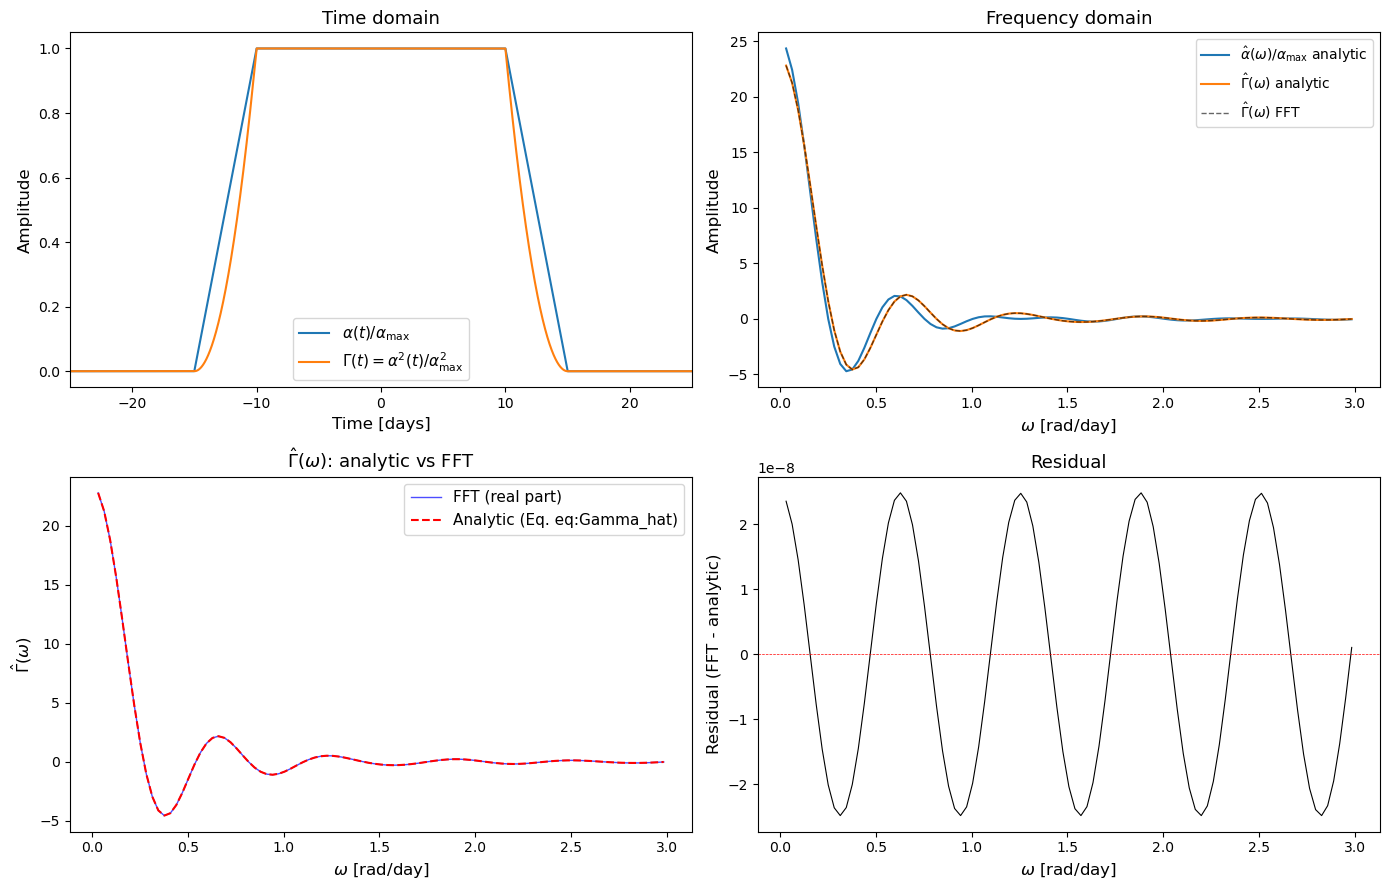

max |FFT - analytic| for 0 < ω < 3: 2.5e-08


In [10]:
# --- Plot comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top left: time domain
ax = axes[0, 0]
ax.plot(t_arr, alpha_t / amax, 'C0-', lw=1.5, label=r'$\alpha(t)/\alpha_{\max}$')
ax.plot(t_arr, Gamma_t, 'C1-', lw=1.5, label=r'$\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$')
ax.set_xlabel('Time [days]', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.set_title('Time domain', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-25, 25)

# Top right: frequency domain comparison
ax = axes[0, 1]
mask = (freqs > 0) & (freqs < 3)
ax.plot(freqs[mask], alpha_hat_ana[mask] / amax, 'C0-', lw=1.5, label=r'$\hat{\alpha}(\omega)/\alpha_{\max}$ analytic')
ax.plot(freqs[mask], Gamma_hat_ana[mask], 'C1-', lw=1.5, label=r'$\hat{\Gamma}(\omega)$ analytic')
ax.plot(freqs[mask], Gamma_hat_fft[mask].real, 'k--', lw=1, alpha=0.6, label=r'$\hat{\Gamma}(\omega)$ FFT')
ax.set_xlabel(r'$\omega$ [rad/day]', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.set_title('Frequency domain', fontsize=13)
ax.legend(fontsize=10)

# Bottom left: Γ̂ analytic vs FFT
ax = axes[1, 0]
ax.plot(freqs[mask], Gamma_hat_fft[mask].real, 'b-', lw=1, alpha=0.7, label='FFT (real part)')
ax.plot(freqs[mask], Gamma_hat_ana[mask], 'r--', lw=1.5, label='Analytic (Eq. eq:Gamma_hat)')
ax.set_xlabel(r'$\omega$ [rad/day]', fontsize=12)
ax.set_ylabel(r'$\hat{\Gamma}(\omega)$', fontsize=12)
ax.set_title(r'$\hat{\Gamma}(\omega)$: analytic vs FFT', fontsize=13)
ax.legend(fontsize=11)

# Bottom right: residual
ax = axes[1, 1]
residual = Gamma_hat_fft[mask].real - Gamma_hat_ana[mask]
ax.plot(freqs[mask], residual, 'k-', lw=0.8)
ax.axhline(0, color='red', ls='--', lw=0.5)
ax.set_xlabel(r'$\omega$ [rad/day]', fontsize=12)
ax.set_ylabel('Residual (FFT - analytic)', fontsize=12)
ax.set_title('Residual', fontsize=13)
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))

fig.tight_layout()
plt.show()

print(f"max |FFT - analytic| for 0 < ω < 3: {np.max(np.abs(residual)):.1e}")
assert np.max(np.abs(residual)) < 1e-5 * (ell_val + 2*tau_val/3)

## 3. High-frequency decay: $\hat\alpha$ and $\hat\Gamma$ both fall off as $\omega^{-2}$

The asymptotic decay of a Fourier transform is set by the lowest derivative that jumps:
- $\alpha(t)$ has slope jumps of size $\alpha_{\max}/\tau$ at all four corners ($|t| = \ell/2$ and $|t| = \ell/2 + \tau$), so $\hat\alpha \sim \omega^{-2}$.
- Squaring smooths only the outer corners: at $|t| = \ell/2 + \tau$ both $\Gamma$ and $\Gamma'$ vanish and only $\Gamma''$ jumps (by $2/\tau^2$), which contributes at order $\omega^{-3}$. The inner corners at $|t| = \ell/2$, where the parabolic ramp meets the plateau, are still kinks ($\Gamma'$ jumps by $2/\tau$), so $\hat\Gamma \sim \omega^{-2}$ as well.

This is visible in Eq. `eq:Gamma_hat`: despite its $\omega^{-3}$ prefactor, the $\tau\omega\cos(\omega\ell/2)$ term gives
$$\hat\Gamma(\omega) = \frac{4\cos(\omega\ell/2)}{\tau\,\omega^2} + \frac{4}{\tau^2\omega^3}\left[\sin\!\left(\frac{\omega\ell}{2}\right) - \sin\!\left(\frac{\omega\ell}{2} + \omega\tau\right)\right],$$
so $|\hat\Gamma| \le 4/(\tau\omega^2) + 8/(\tau^2\omega^3)$ and $S_\Gamma(\omega) = |\hat\Gamma(\omega)|^2 \sim \omega^{-4}$. The same envelope $4/(\tau\omega^2)$ bounds $|\hat\alpha|/\alpha_{\max}$; only the $\omega^{-3}$ remainder of $\hat\Gamma$ comes from the parabolic outer ramps.

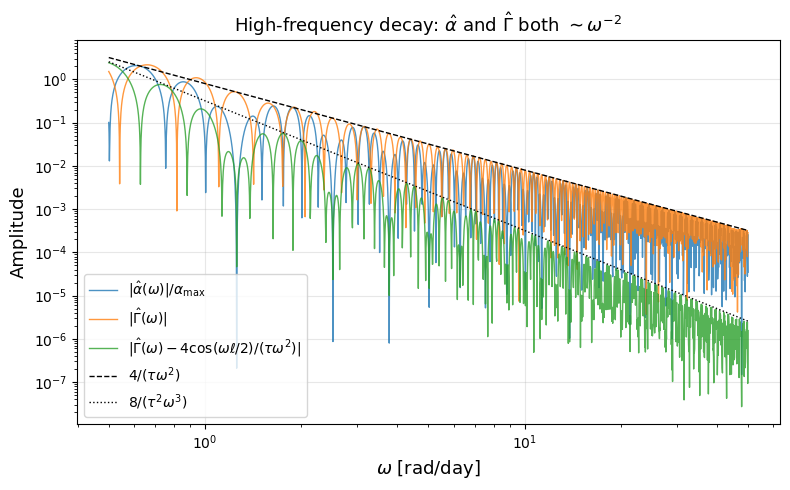

ω in [10, 20]:  max ω²|Γ̂| = 0.815,  max ω²|α̂|/α_max = 0.800   (4/τ = 0.800)
ω in [20, 50]:  max ω²|Γ̂| = 0.808,  max ω²|α̂|/α_max = 0.800   (4/τ = 0.800)


In [11]:
omega_hf = np.logspace(np.log10(0.5), np.log10(50), 2000)

alpha_hat_hf = np.abs(alpha_hat_analytic(omega_hf, ell_val, tau_val, amax)) / amax
Gamma_hat_hf = np.abs(Gamma_hat_analytic(omega_hf, ell_val, tau_val))
# remainder after removing the omega^-2 kink term 4 cos(omega ell/2) / (tau omega^2)
Gamma_rem_hf = np.abs(Gamma_hat_analytic(omega_hf, ell_val, tau_val)
                      - 4 * np.cos(omega_hf * ell_val / 2) / (tau_val * omega_hf**2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(omega_hf, alpha_hat_hf, 'C0-', lw=1, alpha=0.8, label=r'$|\hat{\alpha}(\omega)|/\alpha_{\max}$')
ax.loglog(omega_hf, Gamma_hat_hf, 'C1-', lw=1, alpha=0.8, label=r'$|\hat{\Gamma}(\omega)|$')
ax.loglog(omega_hf, Gamma_rem_hf, 'C2-', lw=1, alpha=0.8,
          label=r'$|\hat{\Gamma}(\omega) - 4\cos(\omega\ell/2)/(\tau\omega^2)|$')

# Reference envelopes
ax.loglog(omega_hf, 4 / (tau_val * omega_hf**2), 'k--', lw=1, label=r'$4/(\tau\omega^{2})$')
ax.loglog(omega_hf, 8 / (tau_val**2 * omega_hf**3), 'k:', lw=1, label=r'$8/(\tau^{2}\omega^{3})$')

ax.set_xlabel(r'$\omega$ [rad/day]', fontsize=13)
ax.set_ylabel('Amplitude', fontsize=13)
ax.set_title(r'High-frequency decay: $\hat{\alpha}$ and $\hat{\Gamma}$ both $\sim\omega^{-2}$', fontsize=13)
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quantitative check on a dense linear grid: omega^2 |Gamma_hat| does not decay; its envelope is 4/tau
assert np.all(Gamma_rem_hf <= 8 / (tau_val**2 * omega_hf**3) * (1 + 1e-9))
for lo, hi in [(10, 20), (20, 50)]:
    wg = np.linspace(lo, hi, 200001)
    env_G = np.max(wg**2 * np.abs(Gamma_hat_analytic(wg, ell_val, tau_val)))
    env_a = np.max(wg**2 * np.abs(alpha_hat_analytic(wg, ell_val, tau_val, amax)) / amax)
    print(f"ω in [{lo}, {hi}]:  max ω²|Γ̂| = {env_G:.3f},  max ω²|α̂|/α_max = {env_a:.3f}   (4/τ = {4/tau_val:.3f})")
    assert abs(env_G - 4 / tau_val) < 8 / (tau_val**2 * lo) + 1e-3

## 4. Verification via self-convolution

Since $\Gamma(t) = \alpha(t)\cdot\alpha(t)/\alpha_{\max}^2$, the multiplication property (`ft:multiplication`) gives
$$\hat{\Gamma}(\omega) = \frac{1}{2\pi\,\alpha_{\max}^2}\,(\hat{\alpha} \ast \hat{\alpha})(\omega).$$
Verify this numerically, using the analytic $\hat\alpha$ on the FFT frequency grid.

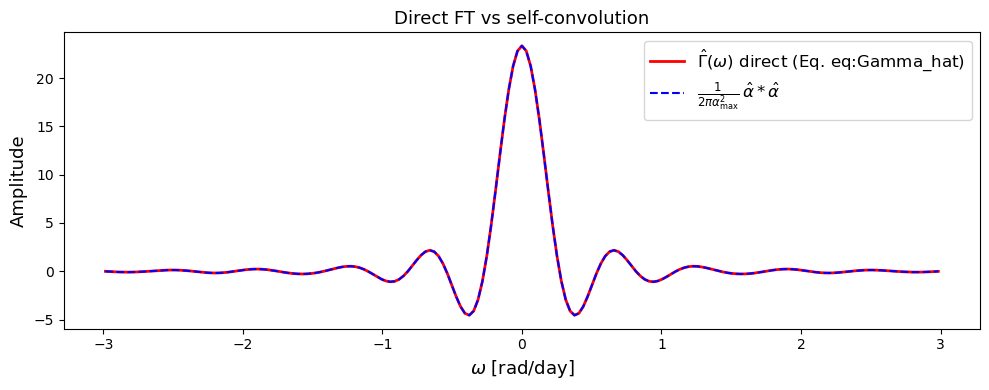

Max relative error (convolution vs direct): 5.30e-10


In [12]:
# Self-convolution: FT of alpha^2 = (1/2pi) alpha_hat * alpha_hat, and Gamma = alpha^2 / alpha_max^2.
# Discrete version on the frequency grid: conv(f, g) = IFFT(FFT(f) * FFT(g)) * dw
dw = freqs[1] - freqs[0]  # frequency spacing

alpha_hat_vals = alpha_hat_ana  # analytic alpha_hat on the frequency grid
conv_result = np.fft.fftshift(
    np.fft.ifft(
        np.fft.fft(np.fft.ifftshift(alpha_hat_vals)) *
        np.fft.fft(np.fft.ifftshift(alpha_hat_vals))
    )
).real * dw / (2 * np.pi * amax**2)

fig, ax = plt.subplots(figsize=(10, 4))
mask2 = (freqs > -3) & (freqs < 3)
ax.plot(freqs[mask2], Gamma_hat_ana[mask2], 'r-', lw=2, label=r'$\hat{\Gamma}(\omega)$ direct (Eq. eq:Gamma_hat)')
ax.plot(freqs[mask2], conv_result[mask2], 'b--', lw=1.5,
        label=r'$\frac{1}{2\pi\alpha_{\max}^2}\,\hat{\alpha} * \hat{\alpha}$')
ax.set_xlabel(r'$\omega$ [rad/day]', fontsize=13)
ax.set_ylabel('Amplitude', fontsize=13)
ax.set_title('Direct FT vs self-convolution', fontsize=13)
ax.legend(fontsize=12)
fig.tight_layout()
plt.show()

# Check max relative error
valid = np.abs(Gamma_hat_ana[mask2]) > 0.01
rel_err = np.abs(conv_result[mask2][valid] - Gamma_hat_ana[mask2][valid]) / np.abs(Gamma_hat_ana[mask2][valid])
print(f"Max relative error (convolution vs direct): {rel_err.max():.2e}")
assert rel_err.max() < 1e-6

## 5. Summary

For the normalized squared trapezoid $\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$ (Eq. `eq:Gamma_piecewise`):

$$\boxed{\hat{\Gamma}(\omega) = \frac{4}{\tau^2\omega^3}\left[\tau\omega\cos\!\left(\frac{\omega\ell}{2}\right) + \sin\!\left(\frac{\omega\ell}{2}\right) - \sin\!\left(\frac{\omega\ell}{2} + \omega\tau\right)\right]}$$

which is Eq. `eq:Gamma_hat` (= Eq. `eq:Gamma_hat_direct`) with $\ell = \ell_{\rm spot}$, $\tau = \tau_{\rm spot}$, with DC value $\hat{\Gamma}(0) = \ell + 2\tau/3$ (the area under $\Gamma$). The transform of the unnormalized $\alpha^2(t)$ is $\alpha_{\max}^2\,\hat\Gamma(\omega)$; the paper carries that $\alpha_{\max}^2$ (as $\alpha_{\max}^4$ in $\mathcal{K}$) separately.

| Property | $\hat{\alpha}(\omega)$ (`ft_trapezoid.ipynb`; not typeset in the paper) | $\hat{\Gamma}(\omega)$ (Eq. `eq:Gamma_hat`) |
|----------|----------------------|------------------------|
| Ramp shape | Linear | Parabolic |
| Integrations by parts per ramp | 1 | 2 (Eqs. `eq:J_ibp`, `eq:I2_ramp`) |
| High-frequency decay | $\omega^{-2}$ (kinks at all four corners) | $\omega^{-2}$ (kinks at $\lvert t\rvert = \ell/2$; the outer corners only add $\omega^{-3}$) |
| DC value | $\alpha_{\max}(\ell + \tau)$ | $\ell + 2\tau/3$ |
| Bracket structure | $\cos$ difference | $\tau\omega\cos + \sin$ difference |